# Merge normative model


Suppose two remote locations independently train a normative model on their own patient population. These remote locations do not want to share their data with you. They can however share their trained models with you, and you can merge them into one bigger model that will have indirectly learned from all datasets. This tutorial will demostrate how to do this merge.

The models being merged do not even need to be of the same type. For example, you can merge a Hierarchical Bayesian Regression (`HBR`) model with a Bayesian Linear Regression (`BLR`) model. The resulting model takes the type and configuration of the **first** model in the list.

## What we will do

1. *Load* the fcon1000 dataset and split it into two groups
2. *Train* a separate model on each subset (one HBR, one BLR)
3. *Visualize* the individually trained models
4. *Merge* the two models into one
5. *Visualize* the merged model predicting across the full dataset

## Functions we will use

| Function | Role |
|---|---|
| `NormativeModel.fit_predict()` | Fit a model on training data and predict on test data |
| `NormativeModel.merge()` | Merge multiple independently trained models into one |


## Imports


In [1]:
from pcntoolkit import load_fcon1000, HBR, NormativeModel, BLR
from pcntoolkit.util.plotter import plot_centiles_advanced
import matplotlib.pyplot as plt
import pcntoolkit
import seaborn as sns

import pandas as pd
import logging
import warnings


# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

## Load and split the data

We use the [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html) dataset, which contains MRI-derived brain measures from 1,078 subjects across 23 imaging sites.

We split the sites into two fixed subsets by assigning 11 sites to one remote location and the remaining 12 sites to the other.

In [2]:
# Load the FCON data
data = load_fcon1000()
# Drop all but the first response var
data = data.sel({"response_vars": data.response_vars[:1]})

# Use 11 sites for Location 1 and the rest 12 for Location 2
all_sites = data.unique_batch_effects["site"]
selected_sites = all_sites[1:5] + all_sites[16:23]

# Split by those sites
location1_data, location2_data = data.batch_effects_split(
    {"site": selected_sites}, names=("location1", "location2")
)

# Split into train and test sets
location1_train, location1_test = location1_data.train_test_split((0.8, 0.2))
location2_train, location2_test = location2_data.train_test_split((0.8, 0.2))

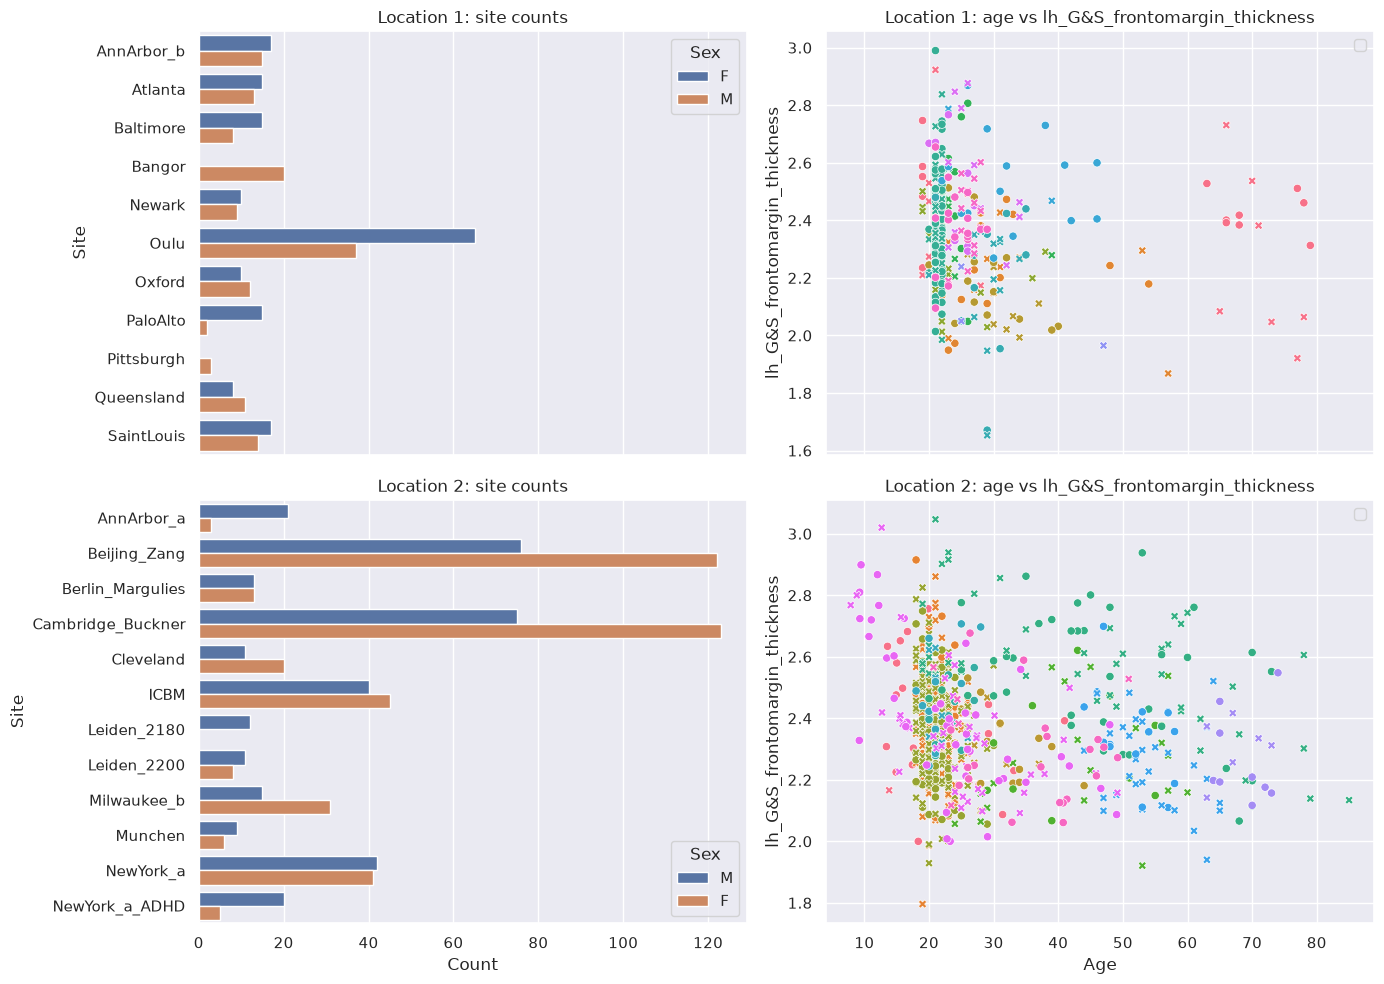

In [3]:
feature = data.response_vars.values[0].item()
datasets = {
    "Location 1": location1_data,
    "Location 2": location2_data,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex="col")

for row, (name, dataset) in enumerate(datasets.items()):
    df = dataset.to_dataframe()

    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[row, 0],
        orient="h",
    )
    axes[row, 0].set_title(f"{name}: site counts")
    axes[row, 0].set_xlabel("Count")
    axes[row, 0].set_ylabel("Site")

    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[row, 1],
    )
    axes[row, 1].set_title(f"{name}: age vs {feature}")
    axes[row, 1].set_xlabel("Age")
    axes[row, 1].set_ylabel(feature)

axes[0, 0].legend(title="Sex")
axes[1, 0].legend(title="Sex")
axes[0, 1].legend([], [])
axes[1, 1].legend([], [])
plt.tight_layout()
plt.show()

---

## Part 1: Train a model at each remote location

Each remote location trains its own normative model independently, without sharing any data. Crucially, the two model types are different:

- **Location 1** uses an `HBR` (PCNtoolkit defaults: Normal likelihood, B-spline basis for μ and σ, random intercept for μ).
- **Location 2** uses a `BLR` with a non-linear warp applied to the response variable, allowing it to capture non-Gaussian distributions.

### Train the Location 1 model (HBR)


In [4]:
location1_model = NormativeModel(HBR(progressbar=False), save_dir="../out/models/location1_model")
location1_model.fit_predict(location1_train, location1_test);


/opt/hostedtoolcache/Python/3.13.14/x64/lib/python3.13/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


### Train the Location 2 model (BLR)


In [5]:
location2_model = NormativeModel(BLR(heteroskedastic=True, warp_name="WarpSinhArcsinh"), save_dir="../out/models/location2_model")
location2_model.fit_predict(location2_train, location2_test);

## Visualize the individual models


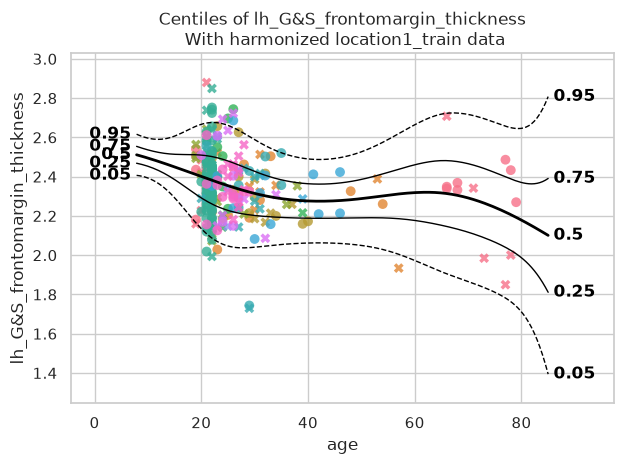

[<Figure size 640x480 with 1 Axes>]

In [6]:
plot_centiles_advanced(location1_model, 
                       scatter_data=location1_train, 
                       covariate_range=(10, 80), 
                       batch_effects="all",
                       show_legend=False
                       )

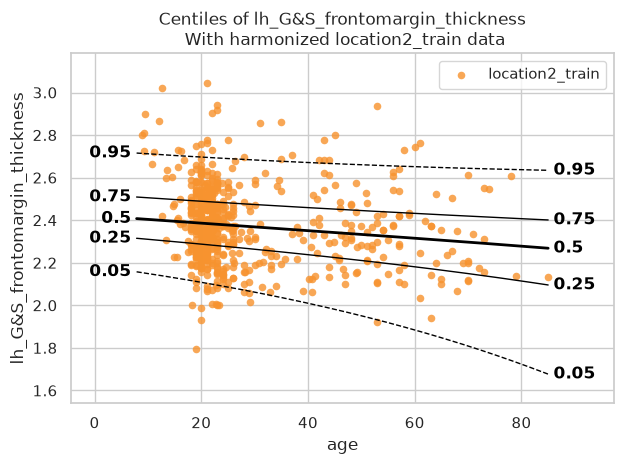

[<Figure size 640x480 with 1 Axes>]

In [7]:
plot_centiles_advanced(location2_model, 
                       scatter_data=location2_train, 
                       covariate_range=(10, 80), 
                       batch_effects="all",
                       show_legend=False
                       )

*Why are all dots in the BLR plot the same orange colour?*

*Answer:* In contrast to the HBR plot above, where each site has its own colour due to site-specific random intercepts in μ, the BLR model does not include explicit site-level random effects. After harmonization, all subjects are therefore combined into a single pooled distribution, which is why all dots in the BLR plot appear in the same orange colour.

---

## Part 2: Merge the two models

The models are now trained and saved to disk. Each remote location shares only the saved model JSON files with you, and not the raw patient data.

To do the merge, you first need to load both models from disk abd then call `NormativeModel.merge()`. Internally, this works by:

1. Generating **synthetic data** from each model's learned distribution
2. Pooling the synthetic datasets together
3. Re-fitting a new model on the combined synthetic data

The result is a model that has *indirectly* learned from both remote locations' populations. Because the merged model takes the type of the first model in the list, the merged model here will be an `HBR`.


In [8]:
# Load the model from disk (could also use the model that we just fitted, but this just shows that you can easily load and merge two models)
fitted_location1_model = NormativeModel.load(location1_model.save_dir)
fitted_location2_model = NormativeModel.load(location2_model.save_dir)

In [9]:
# Merging is super duper easy

# Merge Location 2 into Location 1 — result is a new HBR model (type of the first model in the list).
merged_model = NormativeModel.merge("../out/models/merged_model", [fitted_location1_model, fitted_location2_model]);

# If we would change the order of the models in the list, we would get a BLR model.

## Visualize the merged model

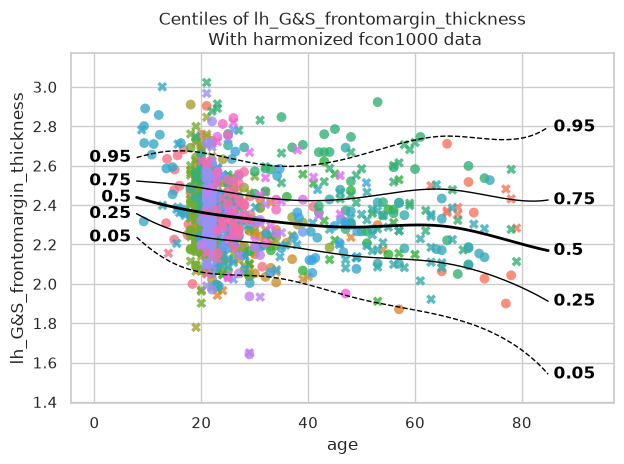

[<Figure size 640x480 with 1 Axes>]

In [10]:
plot_centiles_advanced(merged_model, 
                       scatter_data=data, 
                       covariate_range=(10, 80), 
                       batch_effects="all",
                       show_legend=False)

## Conclusions




Group 2 contains more observations than group 1 in the 10-20 and 40-60 age ranges. So when we merge the two groups we expect a better fit in those age ranges.